# Lecture 5/ AA: Model Selection (non-Machine learning) examples

## Plan:
* OLS
* Forward Selection
* Backwards Selection
* Lasso
* How to compare results

Wiki links:
* OLS:
    * https://en.wikipedia.org/wiki/Ordinary_least_squares
* Forward/Backwards Selection:
    * https://en.wikipedia.org/wiki/Stepwise_regression
* Lasso: 
    * https://en.wikipedia.org/wiki/Lasso_(statistics)

In [1]:
# after we install all the packages, import all of them for the use in today's lecture!
import platform
my_system = platform.uname()
print(f'My PC node: {my_system.node.lower()}')

# optimization
import cvxpy as cp

from pandas.tseries.offsets import BDay

# storage and operations
import pandas as pd
import numpy as np
import datetime
from pathlib import Path
import joblib

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# statistical analysis
from scipy import stats
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf, OAS

# set plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('dark_background')
sns.set_palette("husl")

print('Packages imported successfully!')

My PC node: huangyikaidemacbook-pro.local
Packages imported successfully!


In [4]:
# we can specify some options depending on your computer
class Options:
    path = Path(r'/Users/huangyikai/Documents/FS SEM4/QT/')

print('Data Path: ',Options.path)

# some file names
class FileNames:
    fn_crsp = Options.path / 'crsp.parquet'
    fn_stock_features_labels = Options.path / 'stock_features.parquet'
    fn_option_features = Options.path / 'option_features.parquet'
    fn_ff_factors = Options.path / 'ff_factors.parquet'
    fn_sp500comp = Options.path / 'SP500_Index_Constitutes2024.csv'
    fn_universe = Options.path / 'permno_selection.csv'
    
    # Output files for portfolio optimization results
    fn_portfolio_weights = Options.path / 'portfolio_weights.parquet'
    fn_portfolio_performance = Options.path / 'portfolio_performance.parquet'

Data Path:  /Users/huangyikai/Documents/FS SEM4/QT


In [5]:
'''DEFINE FUNCTIONS TO LOAD THE DATA'''   
def load_ff_crsp():
    """Load Fama-French factors and CRSP stock returns"""
    crsp = pd.read_parquet(FileNames.fn_crsp)
    ff = pd.read_parquet(FileNames.fn_ff_factors)
    return crsp, ff   

# adjust the code to load the features adding the ones from option metrics
def load_features(crsp = True,
                 om = True, 
                  merge = True):
    features_crsp, features_om = pd.DataFrame(), pd.DataFrame()
    if crsp: 
        features_crsp = pd.read_parquet(FileNames.fn_stock_features_labels)
        features_crsp = features_crsp.sort_index()
        pass
    if om:
        features_om = pd.read_parquet(FileNames.fn_option_features)
        features_om = features_om.sort_index()
    if merge:
        res = pd.concat([features_crsp, features_om], axis = 1).sort_index()
    else:
        res = (features_crsp, features_om)
    return res

# Load the data
crsp, ff = load_ff_crsp()
features_crsp = load_features()

print(f"CRSP data shape: {crsp.shape}")
print(f"FF factors shape: {ff.shape}")
if not features_crsp.empty:
    print(f"Features shape: {features_crsp.shape}")

CRSP data shape: (1768460, 12)
FF factors shape: (7550, 7)
Features shape: (1601065, 15)


In [6]:
import statsmodels.api as sm
from sklearn.linear_model import Lasso

def ols_est(X, Y):
    model = sm.OLS(Y, X)
    results = model.fit(disp=0)
    #print(results.summary())
    #print('Parameters: ', results.params)
    #print('R2: ', results.rsquared_adj)
    return results.params, results.rsquared_adj

def lasso_est(X, Y):
    lasso = Lasso(alpha = 0.00001).fit(X, Y)
    #print(lasso.coef_)
    return lasso.coef_

def make_prediction(X, prm):
    return X@prm

In [7]:
def add_factor(X, Y, factors):
    max_r2 = -1000
    max_col = None
    prm_max = None
    for col in X.columns:
        prm, r2_adj = ols_est(X[factors + [col]], Y)
        if r2_adj > max_r2:
            max_col = col
            max_r2 = r2_adj
            prm_max = prm
            
    return factors + [max_col], prm_max, max_r2

def fwd_selection_est(X, Y):
    max_r2 = -1000
    r2_adj = -1000
    max_col = None
    factors = []
    factors_new = []
    while (max_r2 <= r2_adj and len(factors) <= len(list(X.columns))):
        max_r2 = r2_adj
        factors = factors_new
        factors_new, prm, r2_adj = add_factor(X, Y, factors)
    prm_res, r2_adj_tmp = ols_est(X, Y)
    i = 0
    for factor in factors:
        if factor in X.columns:
            prm_res[factor] = prm[i]
        else:
            prm_res[factor] = 0
        i = i + 1
    return prm_res, max_r2

In [8]:
#features_crsp.set_index(['permno','date'], inplace=True)
features_crsp.head()

ret        mktcap    mom12m     mom6m     rev1m  \
permno date                                                               
10104  2014-12-31 -0.008161  200915.32336  0.122049  0.016560  0.068678   
       2015-01-02 -0.014232  197479.77399  0.113319  0.012509  0.050972   
       2015-01-05 -0.013986  194669.29911  0.115964  0.017593  0.039230   
       2015-01-06 -0.010324  191419.68753  0.112789  0.005057  0.032675   
       2015-01-07  0.000232  189443.57238  0.108291 -0.011450  0.031929   

                   beta_mktrf  beta_smb  beta_hml  beta_mom  idvar_ff4  secid  \
permno date                                                                     
10104  2014-12-31    1.141866 -0.269630 -0.541900 -0.223871   0.024360   <NA>   
       2015-01-02    1.140102 -0.258900 -0.539181 -0.221639   0.024561   <NA>   
       2015-01-05    1.123524 -0.252731 -0.542466 -0.200264   0.024600   <NA>   
       2015-01-06    1.124913 -0.251336 -0.540608 -0.201985   0.024602   <NA>   
       2015-01-07    1.116593 -0.245790 -0.519419 -0.212445   0.024808   <NA>   

                   iv_atm  put_skew  call_skew  skew  
permno date                                           
10104  2014-12-31    <NA>      <NA>       <NA>  <NA>  
       2015-01-02    <NA>      <NA>       <NA>  <NA>  
       2015-01-05    <NA>      <NA>       <NA>  <NA>  
       2015-01-06    <NA>      <NA>       <NA>  <NA>  
       2015-01-07    <NA>      <NA>       <NA>  <NA>

In [10]:
dates = sorted(list(features_crsp.index.levels[1].unique())[360:])
pred_horizon = 10
ret_var = f'fret{pred_horizon}d'
pred = {}
vars = ['mom12m',
       'mom6m', 'rev1m',  'beta_mktrf', 'beta_smb', 'beta_hml',
       'beta_mom', 'idvar_ff4']

features_crsp[ret_var] = features_crsp.groupby(level='permno')['ret'].rolling(window=pred_horizon). \
                        apply(lambda x: (x + 1).prod(), raw=True).reset_index(level=0)[['ret']] - 1

features_crsp[ret_var] = features_crsp.groupby(level='permno')[ret_var].shift(-pred_horizon)

features_crsp.dropna(inplace=True)
features_crsp.reset_index(inplace=True)

for d in dates[0:25]:
    print(f"running estimation for date: {d}")
    # very important! you have to use data which was recorded at most {pred_horizon} days ago, 
    # to avoid look ahead bias
    df_insample = features_crsp[np.logical_and(features_crsp['date'] >= d - BDay(252), 
                                               features_crsp['date'] < d - BDay(10))]
    print(f"most recent date in the insample dataset: {df_insample['date'].max()}")
    df_insample = df_insample.replace([np.inf, -np.inf], np.nan).dropna()
    prm_ols, r2_adj = ols_est(df_insample[vars], df_insample[ret_var])
    prm_lasso = lasso_est(df_insample[vars], df_insample[ret_var])
    prm_fwd_selection, max_r2_fwd = fwd_selection_est(df_insample[vars], df_insample[ret_var])

     
    # making a prediction using estimated paramters
    pred[d] = features_crsp[features_crsp['date'] == d - BDay(1)].copy()
    pred[d].loc[:, 'ols_ret'] = make_prediction(features_crsp[vars], prm_ols)
    pred[d].loc[:, 'lasso_ret'] = make_prediction(features_crsp[vars], prm_lasso)
    pred[d].loc[:, 'fwd_ret'] = make_prediction(features_crsp[vars], prm_fwd_selection)
    pred[d] = pred[d][['permno', 'date', ret_var, 'ols_ret', 'lasso_ret', 'fwd_ret']]

df_pred = pd.concat(pred).reset_index(drop=True).dropna()

AttributeError: 'RangeIndex' object has no attribute 'levels'

In [11]:
features_crsp.reset_index(inplace=True)
features_crsp.columns

Index(['index', 'permno', 'date', 'ret', 'mktcap', 'mom12m', 'mom6m', 'rev1m',
       'beta_mktrf', 'beta_smb', 'beta_hml', 'beta_mom', 'idvar_ff4', 'secid',
       'iv_atm', 'put_skew', 'call_skew', 'skew', 'fret10d'],
      dtype='object')

In [12]:
import matplotlib.pyplot as plt

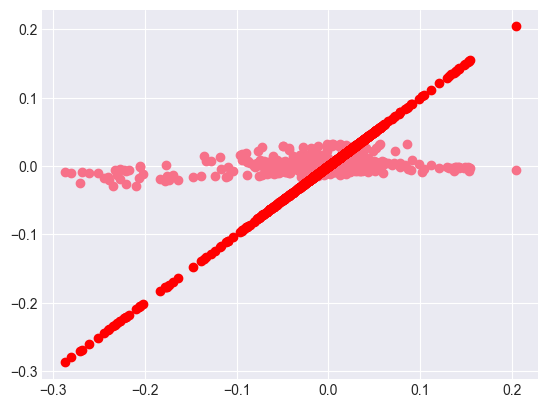

In [13]:
plt.scatter(df_pred[ret_var], df_pred['ols_ret'])
plt.scatter(df_pred[ret_var], df_pred[ret_var], color=['r'])

<Axes: >

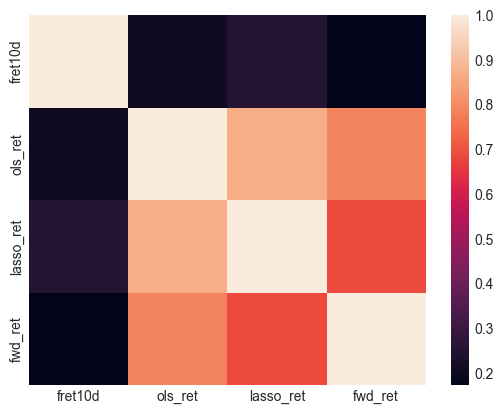

In [14]:
import seaborn as sns
%matplotlib inline

# calculate the correlation matrix on the numeric columns
corr = df_pred[[ret_var, 'ols_ret', 'lasso_ret', 'fwd_ret']].corr()

# plot the heatmap
sns.heatmap(corr)

In [15]:
corr

,fret10d,ols_ret,lasso_ret,fwd_ret
fret10d,1.000000,0.205863,0.251290,0.173575
ols_ret,0.205863,1.000000,0.870392,0.787495
lasso_ret,0.251290,0.870392,1.000000,0.687934
fwd_ret,0.173575,0.787495,0.687934,1.000000
